# 03 — Splits K-Fold Multilabel + Baselines M0 (BCE & ASL)
## Modelagem multilabel relacional com co-ocorrência clínica

**Objetivos:**
1. Divisão robusta: 5-Fold Cross Validation Estratificado Multilabel.
2. Baselines M0 (ResNet-50 com cabeças independentes).
3. Ablação da função de perda: Comparar BCE puro (com `pos_weight`) vs Asymmetric Loss (ASL).
4. OOF (Out-of-Fold) Predictions para estatística consolidada.

**Artefatos Gerados:**
- `project/splits/` — CSVs de treino/val/teste por Fold.
- `project/models/` — checkpoints de M0_BCE e M0_ASL por Fold.
- `project/results/03_baseline_oof_preds.pkl` — predições consolidadas.


In [9]:
!pip install scikit-multilearn-ng

In [10]:
!nvidia-smi

Sat May 16 18:01:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   39C    P0             89W /  600W |    3931MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [11]:
import os, json, hashlib, warnings, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
from skmultilearn.model_selection import IterativeStratification
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

warnings.filterwarnings("ignore")

# ── Paths & Colab Setup ──────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path('/workspace')
    ZIP_PATH = ROOT / 'Dev' / 'Data' / 'Imgs.zip'
    LOCAL_IMGS = Path('/content/Imgs')
    if not LOCAL_IMGS.exists() and ZIP_PATH.exists():
        print("Extraindo imagens para o disco local do Colab...")
        import zipfile
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall('/content/Imgs')
    IMGS_DIR = LOCAL_IMGS / 'Imgs' if (LOCAL_IMGS / 'Imgs').exists() else LOCAL_IMGS
else:
    ROOT = Path(r"/workspace")
    IMGS_DIR = ROOT / "Dev" / "Data" / "Imgs"

DATA_DIR = ROOT / "Dev" / "Data"
CSV_PATH = DATA_DIR / "Imgs-anotadas" / "dataset_labels.csv"

OUT_DIR = ROOT / 'project'
SPLITS_DIR = OUT_DIR / "splits"
MODELS_DIR = OUT_DIR / "models"
RESULTS_DIR= OUT_DIR / "results"
FIGS_DIR = OUT_DIR / "figs"

for d in [SPLITS_DIR, MODELS_DIR, RESULTS_DIR, FIGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LABEL_COLS = ["NORMAL","ALTERADO","SALIVA","LUZ","ENANTEMA",
              "PÓLIPO","ÚLCERA","EROSÃO","MICRONODULARIDADE",
              "ECTASIA VASCULAR","NEOPLASIA"]
CORE_COLS  = ["ENANTEMA","PÓLIPO","ÚLCERA","EROSÃO","MICRONODULARIDADE"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## 1. Carregamento e Curadoria de Dados

In [12]:
df_raw = pd.read_csv(CSV_PATH)
df_raw.rename(columns={"Coluna 1": "image_name"}, inplace=True)

img_files_on_disk = set(f.name for f in IMGS_DIR.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png"))
df_raw["has_file"] = df_raw["image_name"].apply(lambda x: str(x) in img_files_on_disk if pd.notna(x) else False)
df_valid = df_raw[df_raw["has_file"]].copy()

for col in LABEL_COLS:
    df_valid[col] = df_valid[col].fillna(2).map({1: 1, 2: 0})

dup_names = df_valid[df_valid["image_name"].duplicated(keep=False)]["image_name"].unique()
if len(dup_names):
    def merge_dups(g):
        merged = g.iloc[0].copy()
        merged[LABEL_COLS] = g[LABEL_COLS].max() 
        return merged
    df_nodups = df_valid[~df_valid["image_name"].isin(dup_names)]
    df_best = df_valid[df_valid["image_name"].isin(dup_names)].groupby("image_name", group_keys=False).apply(merge_dups)
    if "image_name" not in df_best.columns: df_best = df_best.reset_index()
    df_clean = pd.concat([df_nodups, df_best], ignore_index=True)
else:
    df_clean = df_valid.copy()

# Carregar Mapeamento de Grupos (Pseudo-Pacientes)
groups_path = SPLITS_DIR / "image_group_mapping.csv"
if groups_path.exists():
    df_groups = pd.read_csv(groups_path)
    df_clean = df_clean.merge(df_groups, on="image_name", how="inner")
else:
    df_clean['group_id'] = np.arange(len(df_clean)) # Fallback if run out of order

print(f"Clean dataset: {len(df_clean)} images")
print(f"Total de pseudo-pacientes (groups): {df_clean['group_id'].nunique()}")

Clean dataset: 1990 images
Total de pseudo-pacientes (groups): 1990


## 2. Separação em 5-Folds Estratificados
Com o mapeamento de grupos em mãos (se existirem grupos > 1, devem ser tratados para evitar vazamento), aplicamos a separação `IterativeStratification`., garantindo que as classes raras sejam bem distribuídas pelos Folds.

In [13]:
N_FOLDS = 5
stratifier = IterativeStratification(n_splits=N_FOLDS, order=2)

X = df_clean[["image_name", "group_id"]].values
y = df_clean[CORE_COLS].values.astype(int)

folds_data = []

# Gerar os Folds (Treino 80%, Teste 20%)
for fold, (train_idx, test_idx) in enumerate(stratifier.split(X, y)):
    df_test = df_clean.iloc[test_idx].copy()
    df_train_full = df_clean.iloc[train_idx].copy()
    
    # Do Treino, separar 15% para Validação (early stopping) usando estratificação novamente
    strat_val = IterativeStratification(n_splits=2, order=2, sample_distribution_per_fold=[0.15, 0.85])
    X_tr_full = df_train_full[["image_name"]].values
    y_tr_full = df_train_full[CORE_COLS].values.astype(int)
    
    train_sub_idx, val_sub_idx = next(strat_val.split(X_tr_full, y_tr_full))
    df_val = df_train_full.iloc[val_sub_idx].copy()
    df_train = df_train_full.iloc[train_sub_idx].copy()
    
    folds_data.append({
        'fold': fold,
        'train': df_train,
        'val': df_val,
        'test': df_test
    })
    
    # Salvar CSVs
    df_train.to_csv(SPLITS_DIR / f"fold_{fold}_train.csv", index=False)
    df_val.to_csv(SPLITS_DIR / f"fold_{fold}_val.csv", index=False)
    df_test.to_csv(SPLITS_DIR / f"fold_{fold}_test.csv", index=False)
    
    print(f"Fold {fold}: Train={len(df_train)} Val={len(df_val)} Test={len(df_test)}")

Fold 0: Train=1353 Val=239 Test=398
Fold 1: Train=1353 Val=239 Test=398
Fold 2: Train=1353 Val=239 Test=398
Fold 3: Train=1353 Val=239 Test=398
Fold 4: Train=1353 Val=239 Test=398


## 3. Dataset e Modelos M0 (BCE e ASL)

In [14]:
class EndoDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_names = df['image_name'].values
        self.labels = df[CORE_COLS].values.astype(np.float32)
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.img_names)
        
    def __getitem__(self, idx):
        img_path = self.img_dir / self.img_names[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Transformações com Augmentation leve (sem CutOut/MixUp que quebram co-ocorrência)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_model(num_classes=5):
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    # Dropout para regularização linear simples
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, num_classes)
    )
    return model

# --- Asymmetric Loss ---
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super(AsymmetricLoss, self).__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        # x: logits, y: targets
        x_sigmoid = torch.sigmoid(x)
        xs_pos = x_sigmoid
        xs_neg = 1 - x_sigmoid

        if self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        los_pos = y * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg

        pt0 = xs_pos * y
        pt1 = xs_neg * (1 - y)
        pt = pt0 + pt1
        one_sided_gamma = self.gamma_pos * y + self.gamma_neg * (1 - y)
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)

        loss *= one_sided_w
        return -loss.mean()

## 4. Loop de Treinamento

In [15]:
def train_fold(fold_data, loss_type="BCE", epochs=50, batch_size=32):
    print(f"\n{'='*40}\nIniciando FOLD {fold_data['fold']} - Modelo: {loss_type}\n{'='*40}")
    
    train_loader = DataLoader(EndoDataset(fold_data['train'], IMGS_DIR, train_transform), 
                              batch_size=batch_size, shuffle=True, num_workers=2 if IN_COLAB else 0, pin_memory=True)
    val_loader = DataLoader(EndoDataset(fold_data['val'], IMGS_DIR, eval_transform), 
                            batch_size=batch_size, shuffle=False, num_workers=2 if IN_COLAB else 0, pin_memory=True)
    test_loader = DataLoader(EndoDataset(fold_data['test'], IMGS_DIR, eval_transform), 
                             batch_size=batch_size, shuffle=False, num_workers=2 if IN_COLAB else 0, pin_memory=True)
                             
    model = get_model(len(CORE_COLS)).to(DEVICE)
    optimizer = optim.AdamW([
        {'params': model.conv1.parameters(), 'lr': 1e-5},
        {'params': model.bn1.parameters(), 'lr': 1e-5},
        {'params': model.layer1.parameters(), 'lr': 1e-5},
        {'params': model.layer2.parameters(), 'lr': 1e-5},
        {'params': model.layer3.parameters(), 'lr': 5e-5},
        {'params': model.layer4.parameters(), 'lr': 5e-5},
        {'params': model.fc.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    if loss_type == "BCE":
        pos_freq = fold_data['train'][CORE_COLS].sum().values
        neg_freq = len(fold_data['train']) - pos_freq
        pos_weight = torch.tensor(neg_freq / np.maximum(pos_freq, 1), dtype=torch.float32).to(DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)
        
    best_val_f1 = 0.0
    best_model_path = MODELS_DIR / f"M0_{loss_type}_fold{fold_data['fold']}.pth"
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            
        scheduler.step()
        train_loss /= len(train_loader.dataset)
        
        # Validation
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                all_preds.append(torch.sigmoid(outputs).cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
        all_preds = np.vstack(all_preds)
        all_labels = np.vstack(all_labels)
        
        # Threshold fixo para monitoramento em validação
        val_preds_bin = (all_preds > 0.5).astype(int)
        val_f1 = f1_score(all_labels, val_preds_bin, average='macro', zero_division=0)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)
            
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:02d}/{epochs-1} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f} (Best: {best_val_f1:.4f})")
            
    # --- TEST PREDICTIONS (OOF) ---
    model.load_state_dict(torch.load(best_model_path, weights_only=True))
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(DEVICE))
            test_preds.append(torch.sigmoid(outputs).cpu().numpy())
            test_labels.append(labels.numpy())
            
    return np.vstack(test_preds), np.vstack(test_labels), fold_data['test']['image_name'].values

## 5. Execução Completa e Consolidação (OOF)
*Atenção: Rodar os 5 folds requer GPU e tempo. Caso esteja apenas testando, reduza as epochs.*

In [16]:
# Dicionário para armazenar as predições Out-Of-Fold (OOF)
oof_results = {
    'M0_BCE': {'preds': [], 'labels': [], 'images': []},
    'M0_ASL': {'preds': [], 'labels': [], 'images': []}
}

EPOCHS = 50 # Ajuste para >20 em experimento final

for fold_data in folds_data:
    # Treinar M0_BCE
    p, l, i = train_fold(fold_data, loss_type="BCE", epochs=EPOCHS)
    oof_results['M0_BCE']['preds'].extend(p)
    oof_results['M0_BCE']['labels'].extend(l)
    oof_results['M0_BCE']['images'].extend(i)
    
    # Treinar M0_ASL
    p, l, i = train_fold(fold_data, loss_type="ASL", epochs=EPOCHS)
    oof_results['M0_ASL']['preds'].extend(p)
    oof_results['M0_ASL']['labels'].extend(l)
    oof_results['M0_ASL']['images'].extend(i)

# Salvar o pickle com os resultados OOF
with open(RESULTS_DIR / "03_baseline_oof_preds.pkl", "wb") as f:
    pickle.dump(oof_results, f)

print("\n✅ Treinamento dos Baselines (5 Folds) concluído e predições OOF salvas!")


Iniciando FOLD 0 - Modelo: BCE
Epoch 00/49 | Train Loss: 1.2648 | Val F1: 0.2966 (Best: 0.2966)
Epoch 05/49 | Train Loss: 0.3177 | Val F1: 0.3721 (Best: 0.3721)
Epoch 10/49 | Train Loss: 0.1476 | Val F1: 0.3544 (Best: 0.4075)
Epoch 15/49 | Train Loss: 0.1345 | Val F1: 0.3647 (Best: 0.4550)
Epoch 20/49 | Train Loss: 0.0490 | Val F1: 0.4205 (Best: 0.4550)
Epoch 25/49 | Train Loss: 0.0278 | Val F1: 0.3716 (Best: 0.4550)
Epoch 30/49 | Train Loss: 0.0205 | Val F1: 0.3783 (Best: 0.4550)
Epoch 35/49 | Train Loss: 0.0140 | Val F1: 0.3322 (Best: 0.4550)
Epoch 40/49 | Train Loss: 0.0113 | Val F1: 0.3170 (Best: 0.4550)
Epoch 45/49 | Train Loss: 0.0123 | Val F1: 0.3566 (Best: 0.4550)
Epoch 49/49 | Train Loss: 0.0111 | Val F1: 0.3654 (Best: 0.4550)

Iniciando FOLD 0 - Modelo: ASL
Epoch 00/49 | Train Loss: 0.0370 | Val F1: 0.1982 (Best: 0.1982)
Epoch 05/49 | Train Loss: 0.0127 | Val F1: 0.3759 (Best: 0.4249)
Epoch 10/49 | Train Loss: 0.0043 | Val F1: 0.4159 (Best: 0.4301)
Epoch 15/49 | Train Loss: 

In [17]:
# --- Rápida avaliação global ---
for model_name, data in oof_results.items():
    preds = np.array(data['preds'])
    labels = np.array(data['labels'])
    
    map_score = average_precision_score(labels, preds, average='macro')
    auc_score = roc_auc_score(labels, preds, average='macro')
    f1 = f1_score(labels, (preds > 0.5).astype(int), average='macro', zero_division=0)
    
    print(f"[{model_name}] Global OOF Metrics:")
    print(f"  mAP (AUPRC): {map_score:.4f}")
    print(f"  Macro-AUC  : {auc_score:.4f}")
    print(f"  Macro-F1   : {f1:.4f}\n")

[M0_BCE] Global OOF Metrics:
  mAP (AUPRC): 0.5463
  Macro-AUC  : 0.8995
  Macro-F1   : 0.5349

[M0_ASL] Global OOF Metrics:
  mAP (AUPRC): 0.5014
  Macro-AUC  : 0.8813
  Macro-F1   : 0.4993



## 6. Salvar Métricas e Gerar Gráficos
Aqui salvamos as métricas no formato consolidado JSON e geramos as curvas ROC e PR (Precision-Recall) para o artigo.

Métricas consolidadas salvas em 03_baseline_results.json


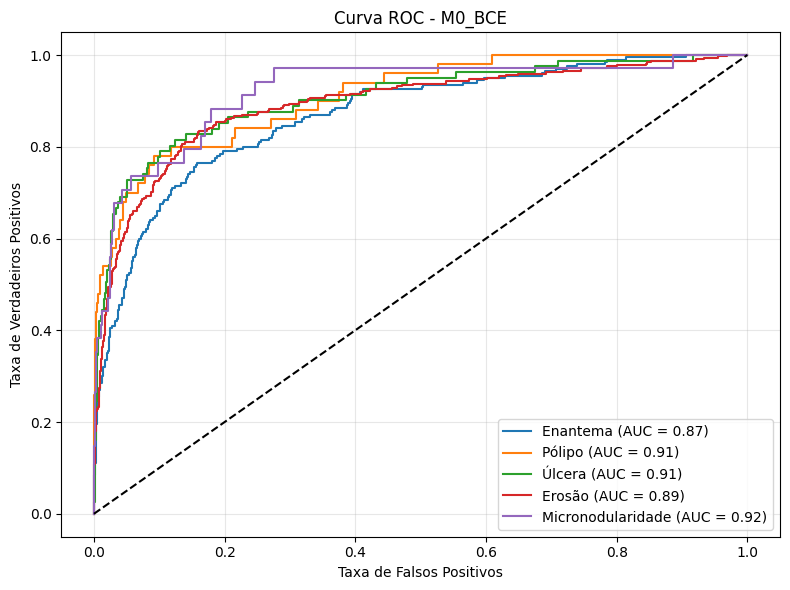

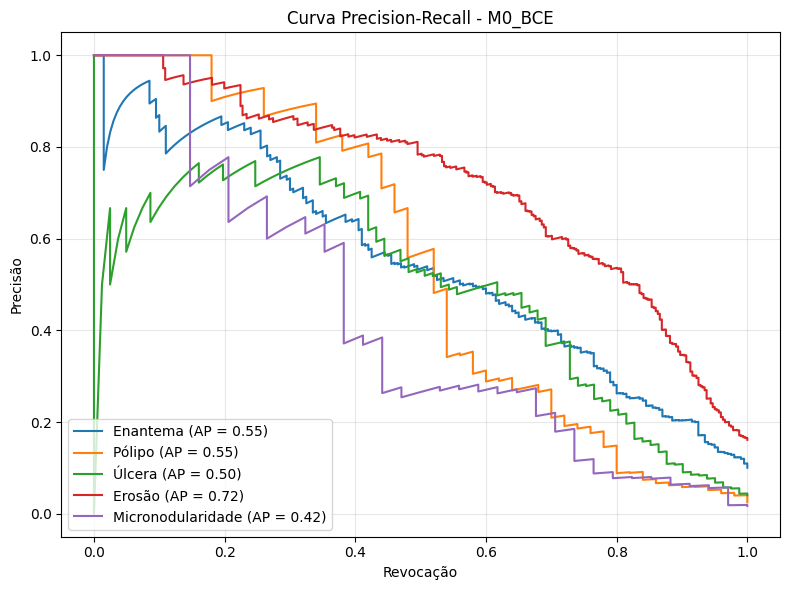

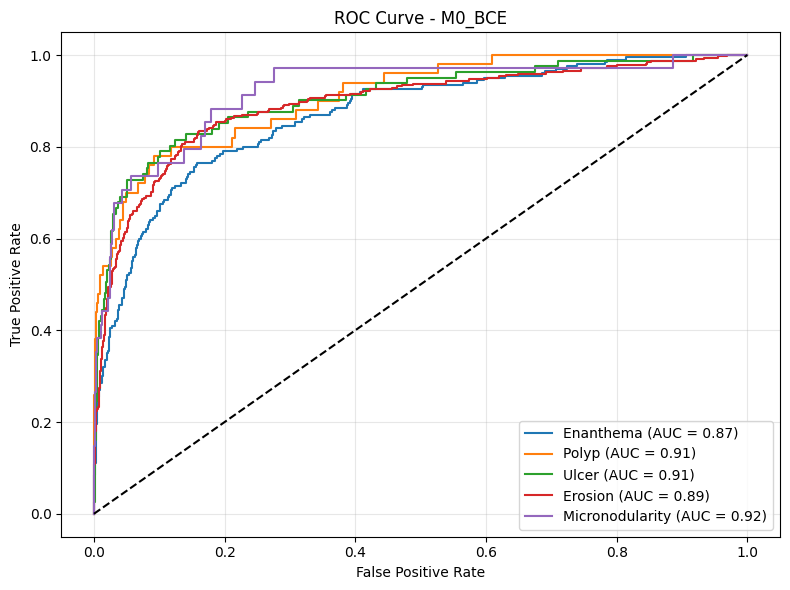

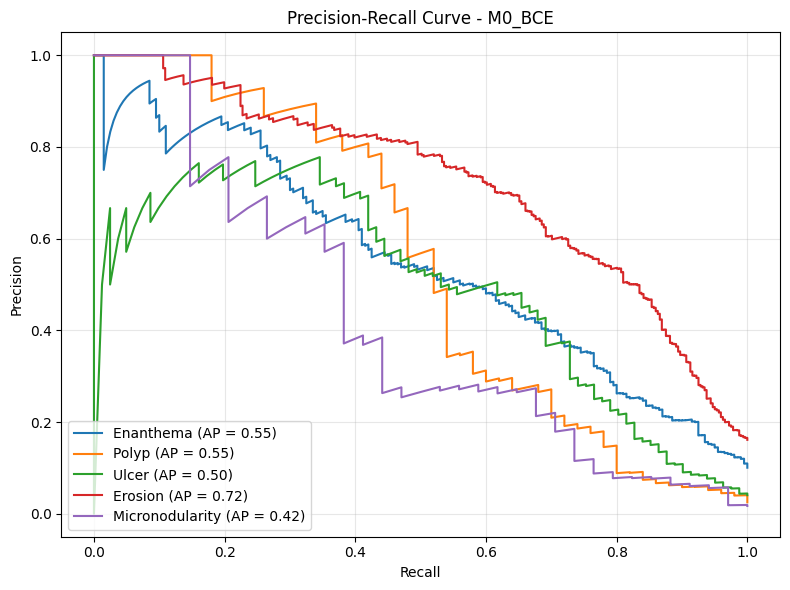

In [18]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

final_metrics = {}

for model_name, data in oof_results.items():
    preds = np.array(data['preds'])
    labels = np.array(data['labels'])
    
    map_score = average_precision_score(labels, preds, average='macro')
    auc_score = roc_auc_score(labels, preds, average='macro')
    f1 = f1_score(labels, (preds > 0.5).astype(int), average='macro', zero_division=0)
    
    final_metrics[model_name] = {
        "mAP": float(map_score),
        "Macro-AUC": float(auc_score),
        "Macro-F1": float(f1)
    }

# Salvar JSON
with open(RESULTS_DIR / "03_baseline_results.json", "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=4)
print("Métricas consolidadas salvas em 03_baseline_results.json")

# --- Gerar Gráficos Separados e Bilíngues (PT / EN) ---
best_model = max(final_metrics, key=lambda m: final_metrics[m]["mAP"])
preds = np.array(oof_results[best_model]['preds'])
labels = np.array(oof_results[best_model]['labels'])

dict_pt = {
    "ENANTEMA": "Enantema",
    "PÓLIPO": "Pólipo",
    "ÚLCERA": "Úlcera",
    "EROSÃO": "Erosão",
    "MICRONODULARIDADE": "Micronodularidade"
}

dict_en = {
    "ENANTEMA": "Enanthema",
    "PÓLIPO": "Polyp",
    "ÚLCERA": "Ulcer",
    "EROSÃO": "Erosion",
    "MICRONODULARIDADE": "Micronodularity"
}

configs = [
    ("PT", dict_pt, "Taxa de Falsos Positivos", "Taxa de Verdadeiros Positivos", "Revocação", "Precisão", "Curva ROC", "Curva Precision-Recall"),
    ("EN", dict_en, "False Positive Rate", "True Positive Rate", "Recall", "Precision", "ROC Curve", "Precision-Recall Curve")
]

for lang, label_map, fpr_label, tpr_label, rec_label, prec_label, roc_title, pr_title in configs:
    
    # 1. Plot ROC Curve Separado
    plt.figure(figsize=(8, 6))
    for i, col in enumerate(CORE_COLS):
        fpr, tpr, _ = roc_curve(labels[:, i], preds[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_map[col]} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{roc_title} - {best_model}")
    plt.xlabel(fpr_label)
    plt.ylabel(tpr_label)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f"03_roc_curve_{best_model}_{lang}.png", dpi=300)
    plt.show()
    
    # 2. Plot Precision-Recall Curve Separado
    plt.figure(figsize=(8, 6))
    for i, col in enumerate(CORE_COLS):
        precision, recall, _ = precision_recall_curve(labels[:, i], preds[:, i])
        ap = average_precision_score(labels[:, i], preds[:, i])
        plt.plot(recall, precision, label=f"{label_map[col]} (AP = {ap:.2f})")
    plt.title(f"{pr_title} - {best_model}")
    plt.xlabel(rec_label)
    plt.ylabel(prec_label)
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f"03_pr_curve_{best_model}_{lang}.png", dpi=300)
    plt.show()
